# eICU Demo — Model A Fairness Pipeline (Patient Ethnicity)

This is the eICU version of the Model A analysis. eICU does not have an insurance field, but it does record patient **ethnicity** — which, like insurance status in MIMIC, is a non-clinical demographic variable that should not influence ICU allocation decisions. If the learned transition dynamics differ across ethnicity groups for patients in identical clinical states, that signals non-clinical bias in the observed data.

State space:
- Clinical: same 81 live states (3⁴ from MAP, SpO₂, GCS, lactate)
- Non-clinical: patient ethnicity — 3 bins
- Total: 3 × 81 + 1 death = **244 states**

`state_A = ethnicity_bin × 81 + clinical_state`

| Ethnicity bin | Group |
|---|---|
| 0 | African American |
| 1 | Hispanic / Other / Unknown |
| 2 | Caucasian |

---
## Section 1 — Setup & Data Loading

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)

BASE_PATH = r'C:\Users\eric\Desktop\Mimic RMAB\data\eicu-demo'
OUT_DIR   = r'C:\Users\eric\Desktop\Mimic RMAB'

print('Base path:', BASE_PATH)
print('Exists:   ', os.path.isdir(BASE_PATH))

Base path: C:\Users\eric\Desktop\Mimic RMAB\data\eicu-demo
Exists:    True


In [2]:
patient = pd.read_csv(
    os.path.join(BASE_PATH, 'patient.csv.gz'), compression='gzip'
)
vitalPeriodic = pd.read_csv(
    os.path.join(BASE_PATH, 'vitalPeriodic.csv.gz'), compression='gzip',
    usecols=['patientunitstayid', 'observationoffset',
             'systemicmean', 'sao2', 'heartrate', 'respiration', 'temperature']
)
nurseCharting = pd.read_csv(
    os.path.join(BASE_PATH, 'nurseCharting.csv.gz'), compression='gzip',
    usecols=['patientunitstayid', 'nursingchartoffset',
             'nursingchartcelltypevallabel', 'nursingchartvalue']
)
lab = pd.read_csv(
    os.path.join(BASE_PATH, 'lab.csv.gz'), compression='gzip',
    usecols=['patientunitstayid', 'labresultoffset', 'labname', 'labresult']
)
hospital = pd.read_csv(
    os.path.join(BASE_PATH, 'hospital.csv.gz'), compression='gzip'
)

for name, df in [('patient', patient), ('vitalPeriodic', vitalPeriodic),
                 ('nurseCharting', nurseCharting), ('lab', lab), ('hospital', hospital)]:
    print(f'{name:<16} shape: {df.shape}')

print('\nHospital region distribution:')
print(hospital['region'].value_counts())
print('\nHospital teachingstatus:')
print(hospital['teachingstatus'].value_counts())

patient          shape: (2520, 29)
vitalPeriodic    shape: (1634960, 7)
nurseCharting    shape: (1477163, 4)
lab              shape: (434660, 4)
hospital         shape: (186, 4)

Hospital region distribution:
region
Midwest      62
South        54
West         39
Northeast    13
Name: count, dtype: int64

Hospital teachingstatus:
teachingstatus
f    168
t     18
Name: count, dtype: int64


---
## Section 2 — Ethnicity Bins

We map eICU's ethnicity field to 3 bins, analogous to MIMIC's Medicaid / Medicare / Other insurance bins:
- Bin 0: African American
- Bin 1: Hispanic + Other/Unknown + Asian + Native American
- Bin 2: Caucasian

In [3]:
ETHNICITY_MAP = {
    'African American': 0,
    'Hispanic':         1,
    'Other/Unknown':    1,
    'Asian':            1,
    'Native American':  1,
    'Caucasian':        2,
}
ETHNICITY_LABELS = {0: 'African American', 1: 'Hispanic/Other', 2: 'Caucasian'}

patient['ethnicity_bin'] = patient['ethnicity'].map(ETHNICITY_MAP).fillna(1).astype(int)

print('Ethnicity bin distribution (patient-stays):')
for b, label in ETHNICITY_LABELS.items():
    n = (patient['ethnicity_bin'] == b).sum()
    print(f'  Bin {b} ({label}): {n:,}')
print(f'\nTotal patient stays: {len(patient):,}')

Ethnicity bin distribution (patient-stays):
  Bin 0 (African American): 231
  Bin 1 (Hispanic/Other): 279
  Bin 2 (Caucasian): 2,010

Total patient stays: 2,520


---
## Section 3 — Daily Backbone

Same as Model B — expand each ICU stay into daily rows, label ICU vs non-ICU days. Attach ethnicity bin from patient table (no hospital join needed).

In [4]:
MINS_PER_DAY = 1440

pat = patient.dropna(
    subset=['hospitaladmitoffset', 'hospitaldischargeoffset',
            'unitdischargeoffset', 'hospitaldischargestatus']
).copy()
for col in ['hospitaladmitoffset', 'hospitaldischargeoffset', 'unitdischargeoffset']:
    pat[col] = pat[col].astype(int)

rows = []
for _, stay in pat.iterrows():
    uid  = stay['patientunitstayid']
    pid  = stay['uniquepid']
    ebin = int(stay['ethnicity_bin'])
    died = int(stay['hospitaldischargestatus'] == 'Expired')

    hosp_admit_day = stay['hospitaladmitoffset']     // MINS_PER_DAY
    icu_disch_day  = stay['unitdischargeoffset']     // MINS_PER_DAY
    hosp_disch_day = stay['hospitaldischargeoffset'] // MINS_PER_DAY

    for day in range(hosp_admit_day, hosp_disch_day + 1):
        is_icu = 1 if (0 <= day <= icu_disch_day) else 0
        rows.append({
            'patientunitstayid': uid,
            'uniquepid':         pid,
            'ethnicity_bin':     ebin,
            'day':               day,
            'is_icu':            is_icu,
            'died':              died,
            'last_day':          hosp_disch_day,
        })

daily = pd.DataFrame(rows)
print(f'Total patient-days: {len(daily):,}')
print(f'ICU days:           {daily["is_icu"].sum():,}')
print(f'Non-ICU days:       {(daily["is_icu"]==0).sum():,}')
print('\nDays by ethnicity bin:')
for b, label in ETHNICITY_LABELS.items():
    n = (daily['ethnicity_bin'] == b).sum()
    print(f'  Bin {b} ({label}): {n:,}')

Total patient-days: 20,377
ICU days:           7,290
Non-ICU days:       13,087

Days by ethnicity bin:
  Bin 0 (African American): 2,201
  Bin 1 (Hispanic/Other): 2,441
  Bin 2 (Caucasian): 15,735


---
## Section 4 — Vitals & Labs

Identical to Model B pipeline.

In [5]:
# vitalPeriodic → daily means
vp = vitalPeriodic.copy()
vp['day'] = vp['observationoffset'] // MINS_PER_DAY
vp_daily = (
    vp.groupby(['patientunitstayid', 'day'])
    .agg(map_vp=('systemicmean','mean'), spo2_vp=('sao2','mean'),
         hr_vp=('heartrate','mean'), rr_vp=('respiration','mean'), temp_vp=('temperature','mean'))
    .reset_index()
)

# nurseCharting → MAP, SpO2, GCS
nc = nurseCharting.copy()
nc['day'] = nc['nursingchartoffset'] // MINS_PER_DAY

def nc_extract(labels, lo=None, hi=None):
    sub = nc[nc['nursingchartcelltypevallabel'].isin(labels)].copy()
    sub['val'] = pd.to_numeric(sub['nursingchartvalue'], errors='coerce')
    if lo is not None: sub = sub[sub['val'] >= lo]
    if hi is not None: sub = sub[sub['val'] <= hi]
    return sub.groupby(['patientunitstayid','day'])['val'].mean().reset_index()

map_nc_daily  = nc_extract(['MAP (mmHg)', 'Arterial Line MAP (mmHg)'], 0, 200).rename(columns={'val': 'map_nc'})
spo2_nc_daily = nc_extract(['O2 Saturation', 'SpO2'], 50, 100).rename(columns={'val': 'spo2_nc'})
gcs_daily     = nc_extract(['Glasgow coma score'], 3, 15).rename(columns={'val': 'gcs_total'})

vitals_daily = vp_daily.merge(map_nc_daily,  on=['patientunitstayid','day'], how='outer')
vitals_daily = vitals_daily.merge(spo2_nc_daily, on=['patientunitstayid','day'], how='outer')
vitals_daily = vitals_daily.merge(gcs_daily,     on=['patientunitstayid','day'], how='outer')

vitals_daily['map']        = vitals_daily['map_vp'].combine_first(vitals_daily['map_nc'])
vitals_daily['spo2']       = vitals_daily['spo2_vp'].combine_first(vitals_daily['spo2_nc'])
vitals_daily['heart_rate'] = vitals_daily['hr_vp']
vitals_daily['resp_rate']  = vitals_daily['rr_vp']
vitals_daily['temperature']= vitals_daily['temp_vp']
vitals_daily = vitals_daily[['patientunitstayid','day','map','spo2','heart_rate','resp_rate','temperature','gcs_total']]

# Lactate
lac = lab[lab['labname']=='lactate'].copy()
lac['day'] = lac['labresultoffset'] // MINS_PER_DAY
lac = lac[lac['labresult'].notna() & (lac['labresult'] > 0)]
labs_raw = lac.groupby(['patientunitstayid','day'])['labresult'].mean().reset_index().rename(columns={'labresult':'lactate'})

patient_days = daily[['patientunitstayid','day']].drop_duplicates()
labs_daily = patient_days.merge(labs_raw, on=['patientunitstayid','day'], how='left')
labs_daily = labs_daily.sort_values(['patientunitstayid','day'])
labs_daily['lactate'] = labs_daily.groupby('patientunitstayid')['lactate'].ffill()

print('vitals_daily:', vitals_daily.shape)
print('labs_daily:  ', labs_daily.shape)

vitals_daily: (10806, 8)
labs_daily:   (20377, 3)


---
## Section 5 — Feature Assembly & Imputation

In [6]:
features = daily.copy()
features = features.merge(vitals_daily, on=['patientunitstayid','day'], how='left')
features = features.merge(labs_daily,   on=['patientunitstayid','day'], how='left')

feature_cols = ['map','spo2','gcs_total','lactate','heart_rate','resp_rate','temperature']

features = features.sort_values(['patientunitstayid','day'])
features[feature_cols] = features.groupby('patientunitstayid')[feature_cols].ffill()
features[feature_cols] = features[feature_cols].fillna(features[feature_cols].median())

print('Features shape:', features.shape)
print('Remaining NaNs:', features[feature_cols].isna().sum().sum())

Features shape: (20377, 14)
Remaining NaNs: 0


---
## Section 6 — State Discretization (Model A)

Clinical bins are identical to Model B. We then augment with the ethnicity bin:

`state_A = ethnicity_bin × 81 + clinical_state`

244 states total (3 × 81 live + 1 death at index 243).

In [7]:
# Clinical bins (same as Model B)
features['map_bin'] = pd.cut(
    features['map'], bins=[-np.inf, 65, 100, np.inf], labels=[0,1,2]).astype(int)
features['spo2_bin'] = pd.cut(
    features['spo2'], bins=[-np.inf, 90, 95, np.inf], labels=[0,1,2]).astype(int)
features['gcs_bin'] = pd.cut(
    features['gcs_total'], bins=[2, 8, 12, 15], labels=[0,1,2]).astype(int)
features['lactate_bin'] = pd.cut(
    features['lactate'], bins=[-np.inf, 2, 4, np.inf], labels=[2,1,0]).astype(int)

N_CLINICAL   = 81
N_ETH_BINS   = 3
N_STATES_A   = N_CLINICAL * N_ETH_BINS + 1  # 244
DEATH_STATE  = N_STATES_A - 1               # 243

features['clinical_state'] = (
    features['map_bin']     * 27 +
    features['spo2_bin']    *  9 +
    features['gcs_bin']     *  3 +
    features['lactate_bin']
)

# Augmented state: ethnicity_bin × 81 + clinical_state
features['state_A'] = features['ethnicity_bin'] * N_CLINICAL + features['clinical_state']

# Death state on last day of fatal stays
died_mask = (features['died'] == 1) & (features['day'] == features['last_day'])
features.loc[died_mask, 'state_A'] = DEATH_STATE

print(f'N_STATES_A = {N_STATES_A}  (DEATH_STATE = {DEATH_STATE})')
print(f'State_A range: {features["state_A"].min()} – {features["state_A"].max()}')
print(f'Unique states observed: {features["state_A"].nunique()} / {N_STATES_A}')
print()
for b, label in ETHNICITY_LABELS.items():
    mask = (features['ethnicity_bin']==b) & (features['state_A'] != DEATH_STATE)
    print(f'Bin {b} ({label}): '
          f'{mask.sum():,} patient-days, '
          f'{features.loc[mask,"state_A"].nunique()} unique states')

N_STATES_A = 244  (DEATH_STATE = 243)
State_A range: 2 – 243
Unique states observed: 91 / 244

Bin 0 (African American): 2,192 patient-days, 23 unique states
Bin 1 (Hispanic/Other): 2,411 patient-days, 24 unique states
Bin 2 (Caucasian): 15,562 patient-days, 43 unique states


---
## Section 7 — Transition Matrix (Model A)

In [8]:
feat_sorted = features.sort_values(['patientunitstayid','day']).reset_index(drop=True)
feat_sorted['state_A_next'] = (
    feat_sorted.groupby('patientunitstayid')['state_A'].shift(-1)
)

transitions = feat_sorted.dropna(subset=['state_A_next']).copy()
transitions['state_A']      = transitions['state_A'].astype(int)
transitions['state_A_next'] = transitions['state_A_next'].astype(int)

print(f'Total transition pairs: {len(transitions):,}')
print(f'  ICU:     {transitions["is_icu"].sum():,}')
print(f'  Non-ICU: {(1 - transitions["is_icu"]).sum():,}')
print()
for b, label in ETHNICITY_LABELS.items():
    n = (transitions['ethnicity_bin'] == b).sum()
    print(f'  {label}: {n:,} transitions')

Total transition pairs: 17,885
  ICU:     6,499
  Non-ICU: 11,386

  African American: 1,973 transitions
  Hispanic/Other: 2,167 transitions
  Caucasian: 13,745 transitions


In [9]:
count_icu_A    = np.zeros((N_STATES_A, N_STATES_A), dtype=np.float64)
count_nonicu_A = np.zeros((N_STATES_A, N_STATES_A), dtype=np.float64)

for _, row in transitions.iterrows():
    s, sn, icu = int(row['state_A']), int(row['state_A_next']), int(row['is_icu'])
    if icu == 1:
        count_icu_A[s, sn]    += 1
    else:
        count_nonicu_A[s, sn] += 1

print(f'ICU    total counts: {count_icu_A.sum():.0f}')
print(f'NonICU total counts: {count_nonicu_A.sum():.0f}')

ICU    total counts: 6499
NonICU total counts: 11386


In [10]:
def normalise_rows(count_mat, n_states):
    prob = count_mat.copy()
    row_sums = prob.sum(axis=1, keepdims=True)
    nonzero  = (row_sums.squeeze() > 0)
    prob[nonzero]  = prob[nonzero] / row_sums[nonzero]
    prob[~nonzero] = 1.0 / n_states
    return prob, (~nonzero).sum()

P_icu_A,    n_zero_icu    = normalise_rows(count_icu_A,    N_STATES_A)
P_nonicu_A, n_zero_nonicu = normalise_rows(count_nonicu_A, N_STATES_A)

for P in (P_icu_A, P_nonicu_A):
    P[DEATH_STATE, :]           = 0.0
    P[DEATH_STATE, DEATH_STATE] = 1.0

print(f'P_icu_A    zero rows: {n_zero_icu}')
print(f'P_nonicu_A zero rows: {n_zero_nonicu}')
print(f'Row-sum P_icu_A:    min={P_icu_A.sum(1).min():.4f}  max={P_icu_A.sum(1).max():.4f}')
print(f'Row-sum P_nonicu_A: min={P_nonicu_A.sum(1).min():.4f}  max={P_nonicu_A.sum(1).max():.4f}')

P_icu_A    zero rows: 166
P_nonicu_A zero rows: 175
Row-sum P_icu_A:    min=1.0000  max=1.0000
Row-sum P_nonicu_A: min=1.0000  max=1.0000


In [11]:
np.save(os.path.join(OUT_DIR, 'P_icu_A_eicu.npy'),    P_icu_A)
np.save(os.path.join(OUT_DIR, 'P_nonicu_A_eicu.npy'), P_nonicu_A)
print(f'Saved P_icu_A_eicu.npy    shape={P_icu_A.shape}')
print(f'Saved P_nonicu_A_eicu.npy shape={P_nonicu_A.shape}')

Saved P_icu_A_eicu.npy    shape=(244, 244)
Saved P_nonicu_A_eicu.npy shape=(244, 244)


---
## Section 8 — Plots

Heatmaps of both matrices and self-loop comparison across region groups for the top clinical states.

In [12]:
obs_A = np.where((count_icu_A.sum(axis=1) + count_nonicu_A.sum(axis=1)) > 0)[0]
print(f'States with ≥1 transition: {len(obs_A)} / {N_STATES_A}')
tick_step = max(1, len(obs_A) // 12)

States with ≥1 transition: 86 / 244


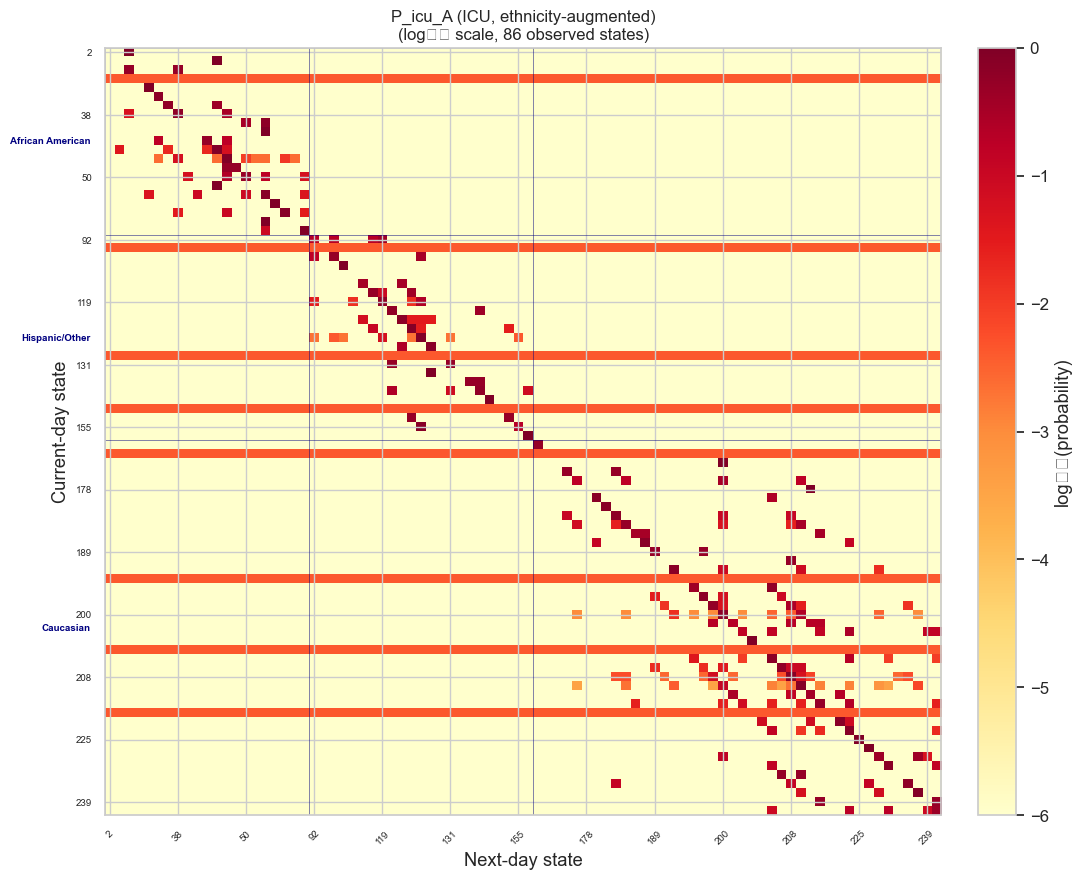

Saved: eicu_heatmap_P_icu_A.png


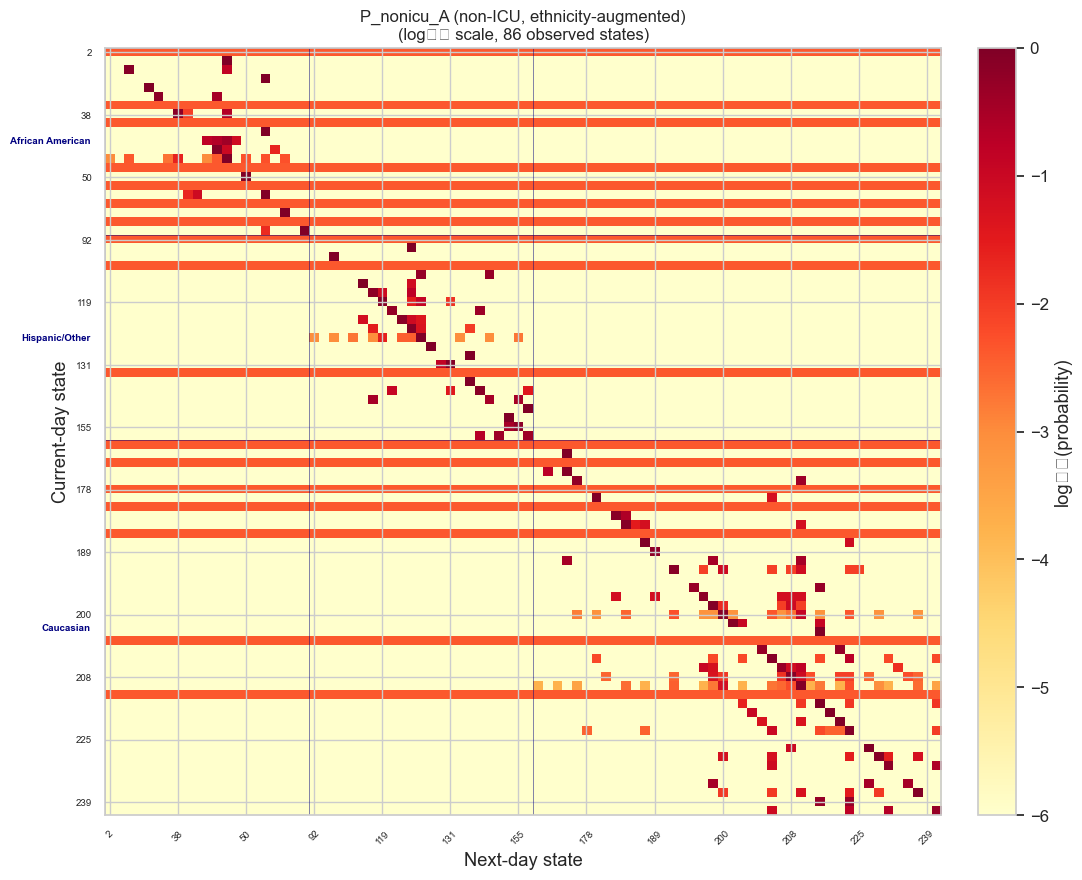

Saved: eicu_heatmap_P_nonicu_A.png


In [13]:
# Heatmaps
for P, fname, title in [
    (P_icu_A,    'eicu_heatmap_P_icu_A.png',    'P_icu_A (ICU, ethnicity-augmented)'),
    (P_nonicu_A, 'eicu_heatmap_P_nonicu_A.png', 'P_nonicu_A (non-ICU, ethnicity-augmented)'),
]:
    P_obs    = P[np.ix_(obs_A, obs_A)]
    data_log = np.log10(np.where(P_obs > 0, P_obs, 1e-6))
    fig, ax  = plt.subplots(figsize=(11, 9))
    im = ax.imshow(data_log, aspect='auto', cmap='YlOrRd', vmin=-6, vmax=0)
    ax.set_title(f'{title}\n(log₁₀ scale, {len(obs_A)} observed states)', fontsize=12)
    ax.set_xlabel('Next-day state'); ax.set_ylabel('Current-day state')
    ax.set_xticks(range(0, len(obs_A), tick_step))
    ax.set_xticklabels(obs_A[::tick_step], rotation=45, fontsize=7)
    ax.set_yticks(range(0, len(obs_A), tick_step))
    ax.set_yticklabels(obs_A[::tick_step], fontsize=7)
    # Ethnicity group boundary lines
    for b in range(N_ETH_BINS):
        grp = [i for i, s in enumerate(obs_A) if s != DEATH_STATE and s // N_CLINICAL == b]
        if grp:
            lo, hi = grp[0] - 0.5, grp[-1] + 0.5
            for line in [lo, hi]:
                ax.axhline(line, color='navy', lw=0.5, alpha=0.4)
                ax.axvline(line, color='navy', lw=0.5, alpha=0.4)
            ax.text(-2, (lo+hi)/2, ETHNICITY_LABELS[b], fontsize=7, va='center',
                    ha='right', color='navy', fontweight='bold')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('log₁₀(probability)')
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, fname), dpi=120)
    plt.show()
    print('Saved:', fname)

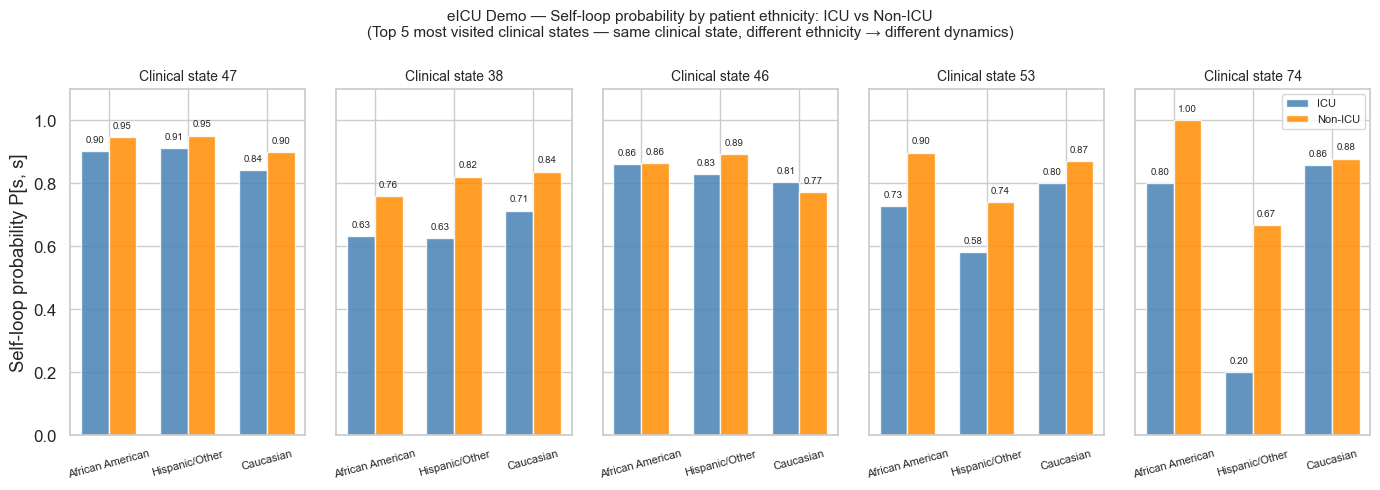

Saved: eicu_selfloop_by_ethnicity.png


In [14]:
# ── Fairness plot: self-loop by ethnicity group for top clinical states ─────────
top_clinical = (
    features[features['state_A'] != DEATH_STATE]['clinical_state']
    .value_counts().head(5).index.tolist()
)

fig, axes = plt.subplots(1, len(top_clinical), figsize=(14, 5), sharey=True)

for ax, clin in zip(axes, top_clinical):
    x = np.arange(N_ETH_BINS)
    icu_vals, nonicu_vals = [], []
    for b in range(N_ETH_BINS):
        s = b * N_CLINICAL + clin
        icu_vals.append(P_icu_A[s, s])
        nonicu_vals.append(P_nonicu_A[s, s])

    width = 0.35
    b1 = ax.bar(x - width/2, icu_vals,    width, color='steelblue',  alpha=0.85, label='ICU')
    b2 = ax.bar(x + width/2, nonicu_vals, width, color='darkorange', alpha=0.85, label='Non-ICU')
    ax.set_title(f'Clinical state {clin}', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([ETHNICITY_LABELS[b] for b in range(N_ETH_BINS)], fontsize=8, rotation=15)
    ax.set_ylim(0, 1.1)
    for bar in list(b1) + list(b2):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

axes[0].set_ylabel('Self-loop probability P[s, s]')
axes[-1].legend(fontsize=8)
fig.suptitle(
    'eICU Demo — Self-loop probability by patient ethnicity: ICU vs Non-ICU\n'
    '(Top 5 most visited clinical states — same clinical state, different ethnicity → different dynamics)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'eicu_selfloop_by_ethnicity.png'), dpi=120)
plt.show()
print('Saved: eicu_selfloop_by_ethnicity.png')

---
## Section 9 — Summary & Fairness Results

In [15]:
print('=' * 60)
print('    eICU MODEL A PIPELINE SUMMARY (Patient Ethnicity)')
print('=' * 60)
print(f'  Dataset                               : eICU-CRD Demo v2.0.1')
print(f'  Fairness variable                     : Patient ethnicity (3 bins)')
print(f'    Bin 0 = African American')
print(f'    Bin 1 = Hispanic / Other / Unknown')
print(f'    Bin 2 = Caucasian')
print(f'  State space (N_STATES_A)              : {N_STATES_A}')
print(f'  Clinical states per group             : {N_CLINICAL}')
print(f'  Death state                           : {DEATH_STATE}')
print(f'  Unique states observed                : {features["state_A"].nunique()}')
print(f'  Total transition pairs                : {len(transitions):,}')
print(f'    ICU                                 : {int(transitions["is_icu"].sum()):,}')
print(f'    Non-ICU                             : {int((1-transitions["is_icu"]).sum()):,}')
print(f'  P_icu_A zero rows (uniform fallback)  : {n_zero_icu}')
print(f'  P_nonicu_A zero rows (uniform fallback): {n_zero_nonicu}')
print('=' * 60)
print()
print('Fairness finding — self-loop differences by ethnicity')
print('(same clinical state, different ethnicity = different P[s,s]):')
print()
for clin in top_clinical[:3]:
    vals_icu    = [P_icu_A[b*N_CLINICAL+clin, b*N_CLINICAL+clin]    for b in range(N_ETH_BINS)]
    vals_nonicu = [P_nonicu_A[b*N_CLINICAL+clin, b*N_CLINICAL+clin] for b in range(N_ETH_BINS)]
    print(f'  Clinical state {clin}:')
    print(f'    {"Group":<22}  ICU self-loop  Non-ICU self-loop')
    for b, label in ETHNICITY_LABELS.items():
        print(f'    {label:<22}  {vals_icu[b]:.3f}          {vals_nonicu[b]:.3f}')
    print(f'    ICU range: {max(vals_icu)-min(vals_icu):.3f}   '
          f'Non-ICU range: {max(vals_nonicu)-min(vals_nonicu):.3f}')
    print()

print('Output files:')
print(f'  P_icu_A_eicu.npy              : {P_icu_A.shape}')
print(f'  P_nonicu_A_eicu.npy           : {P_nonicu_A.shape}')
print(f'  eicu_heatmap_P_icu_A.png')
print(f'  eicu_heatmap_P_nonicu_A.png')
print(f'  eicu_selfloop_by_ethnicity.png')

    eICU MODEL A PIPELINE SUMMARY (Patient Ethnicity)
  Dataset                               : eICU-CRD Demo v2.0.1
  Fairness variable                     : Patient ethnicity (3 bins)
    Bin 0 = African American
    Bin 1 = Hispanic / Other / Unknown
    Bin 2 = Caucasian
  State space (N_STATES_A)              : 244
  Clinical states per group             : 81
  Death state                           : 243
  Unique states observed                : 91
  Total transition pairs                : 17,885
    ICU                                 : 6,499
    Non-ICU                             : 11,386
  P_icu_A zero rows (uniform fallback)  : 166
  P_nonicu_A zero rows (uniform fallback): 175

Fairness finding — self-loop differences by ethnicity
(same clinical state, different ethnicity = different P[s,s]):

  Clinical state 47:
    Group                   ICU self-loop  Non-ICU self-loop
    African American        0.902          0.948
    Hispanic/Other          0.913          0.952
    